# 0.  Giriş

Bu notebookta Pima diabet veri seti kullanarak özellik seçimi yapıp, üç model için (Decision Tree, Random Forest ve Naive Bayes) seçilmiş özelliklerle eğitip, performasnlarını karşılaştırarak, özellik seçimi konusuna kısa bir giriş yapmak istiyorum. Bunu bir makaleyi kaynak olarak alıp, kullanılan yöntemi uygulayarak yapacağım. Orjinal makele: https://pmc.ncbi.nlm.nih.gov/articles/PMC8943493/. 

Sonuçlar makaleden daha düşük accuracy değerlerine karşılık genel olarak daha yüksek specificity değerleri gösteriyor. Burada amaç makaleyi doğrulamak ya da en iyi modelleri bulmak değil, özellik seçiminin sonuçlara etkisini görmek ve özellik seçimi konusuna giriş yapmak. Tüm veri setini kullanma ile üçlü ve beşli özellik setleri ile çalışmanın etkileri makale ile benzer özellikler gösteriyor. Bu notebookun amacı açısından bu kadarı yeterli. Hiperparametre ayarları yapılarak, accuracy değerleri artırılabilir, ancak amaç açısından buna gerek görülmedi.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("diabetes.csv")

## Preprocessing

Kayıp veriler median değerleri ile değiştirildi. PCA uygulamak için veri standardize edildi. Ancak modeller eğitilirken standardize edilmemiş veri kullanıldı.

In [9]:
missing_features = ["Glucose", "BloodPressure","SkinThickness", "Insulin", "BMI"]

In [10]:
df[missing_features] = df[missing_features].replace(0, np.nan)

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [12]:
imputer = SimpleImputer(strategy="median")
df[missing_features] = imputer.fit_transform(df[missing_features])

In [13]:
X = df.drop(["Outcome"], axis=1)
y = df["Outcome"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.299, random_state=42)

In [15]:
scaler = StandardScaler()

In [16]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Feature selection

## 1.1. PCA

İlk işlem PCA: 8 boyutlu veri 2 boyuta indirildi. İki boyut veriyi % 46.79 oranında temsil ediyor. Temsil kadar önemli olan birbirlerine yakın temsil özelliğine sahip değişkenler ayırt edilebildi: Biplot çiziminde Pregnancy ve Age değişkenlerin de görüldüğü gibi.

In [17]:
from sklearn.decomposition import PCA

In [18]:
# 2 boyutlu bir uzayda temsil
pca = PCA(n_components=2)

In [19]:
# Ölçeklenmiş veride PCA uygulandı
df_pca = pca.fit_transform(X_train_scaled)

In [20]:
# İlk 5 örnek
df_pca[:5,]

array([[ 0.12852397,  0.15771688],
       [-2.75262121,  0.26467861],
       [ 0.41884533, -0.37477398],
       [ 0.8595644 , -2.38865622],
       [-0.54414322,  0.24593746]])

In [21]:
# yeni verinin boyutu -> yeni bir veri seti oluşturdu
df_pca.shape

(538, 2)

In [22]:
# PCA'nın veriyi açıklama oranı
print(f"Açıklanan Varyans Oranları: {pca.explained_variance_ratio_}")
print(f"Toplam Korunan Bilgi: %{sum(pca.explained_variance_ratio_)*100:.2f}")

Açıklanan Varyans Oranları: [0.28205398 0.18583195]
Toplam Korunan Bilgi: %46.79


In [23]:
# Her bir özelliğin temsil edilme durumları
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1","PC2"],
    index=df.drop("Outcome", axis=1).columns
)
print(loadings)

                               PC1       PC2
Pregnancies               0.318733  0.525760
Glucose                   0.418124 -0.038260
BloodPressure             0.369450  0.157803
SkinThickness             0.386129 -0.363605
Insulin                   0.282830 -0.152912
BMI                       0.401881 -0.444393
DiabetesPedigreeFunction  0.189056 -0.283390
Age                       0.400935  0.513639


## 1.2. Biplot

PCA verisi üzerinde özelliklerin temsil grafiği

In [24]:
def biplot(score, coeff, labels=None):
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]
    
    # Ölçeklendirme (Vektörlerin görünür olması için)
    scalex =  1.0 / (xs.max() - xs.min())
    scaley =  1.0 / (ys.max() - ys.min())
    
    plt.figure(figsize=(12, 8))
    
    # Noktaları çiz (Scatter Plot)
    scatter = plt.scatter(xs * scalex, ys * scaley, c=y_train, cmap='Set1', alpha=0.5)
    #plt.legend(*scatter.legend_elements(), title="Diyabet (1: Pozitif)")

    # Vektörleri çiz (Loadings)
    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1], color='blue', alpha=0.8, head_width=0.02)
        if labels is None:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, "Var"+str(i+1), color='g', ha='center', va='center')
        else:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color='darkblue', ha='center', va='center', fontweight='bold')

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.title("Pima Diabetes PCA Biplot")

In [25]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

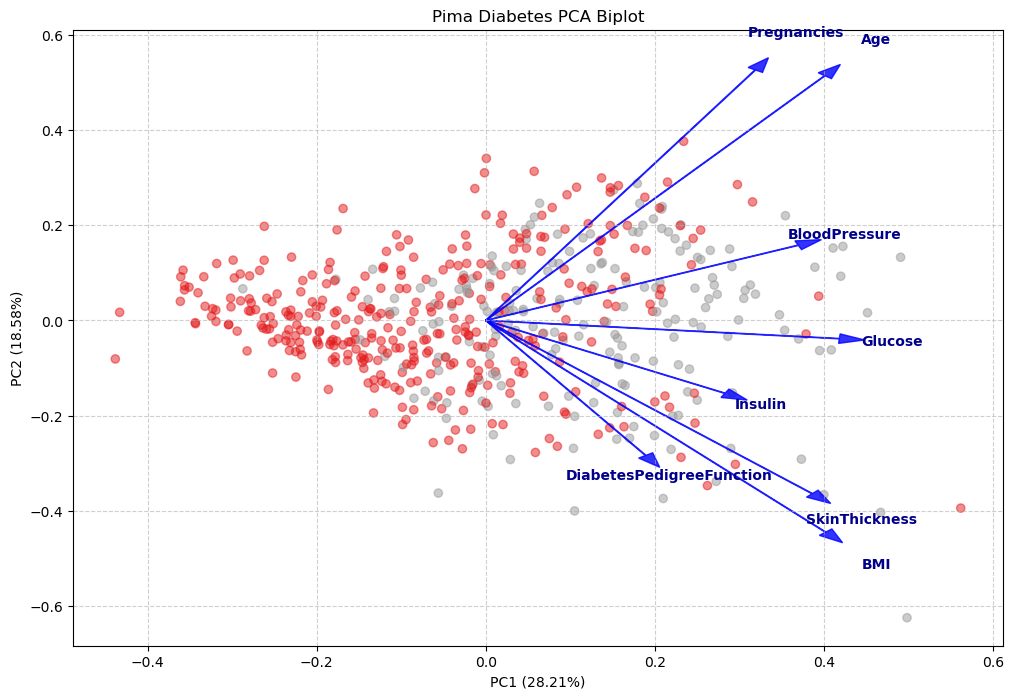

In [26]:
biplot(df_pca, np.transpose(pca.components_), labels=features)
plt.show()

Birbirine yakın vektörler ilgililikleri daha fazla olan özelliklerdir. Gebelik ile yaş, BMI, deri kalınlığı ile DPF birbiriyle ilişkili görünüyor.

## 1.3. k-means kümeleme

PCA verisi üzerinden yapılacak. 2,3 ve 4 kümeye bölme seçenekleri karşılaştırıldı, 2 ve 3 kümeli seçimlerin anlamlı şekilde veriyi ayırabildiği görüldü. 

In [27]:
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull

In [28]:
# 2 sınıflı bir kümeleme
kmeans = KMeans(n_clusters=2)

In [29]:
kmeans.fit(df_pca)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [30]:
# k-means kümelemede kümelerin merkezleri
kmeans.cluster_centers_

array([[-1.06438567, -0.26041131],
       [ 1.35181471,  0.33073335]])

In [31]:
def plot_clusters(X, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X)
    labels = kmeans.labels_
    
    colors = ['#ff7f7f', '#7fbfff', '#7fff7f', '#bf7fff'] # Görseldeki soft renkler
    
    for i in range(n_clusters):
        points = X[labels == i]
        
        # Noktaları çiz
        plt.scatter(points[:, 0], points[:, 1], s=10, label=f'Cluster {i+1}', c=colors[i])
        
        # 2. DIŞBÜKEY ÖRTÜ (Convex Hull) ÇİZİMİ
        if len(points) > 2: # En az 3 nokta lazım
            hull = ConvexHull(points)
            # Bölgeyi boya (alpha ile şeffaflık verilir)
            plt.fill(points[hull.vertices, 0], points[hull.vertices, 1], 
                     c=colors[i], alpha=0.3)
            # Sınır çizgisi
            plt.plot(points[hull.vertices, 0], points[hull.vertices, 1], 
                     c=colors[i], lw=1)

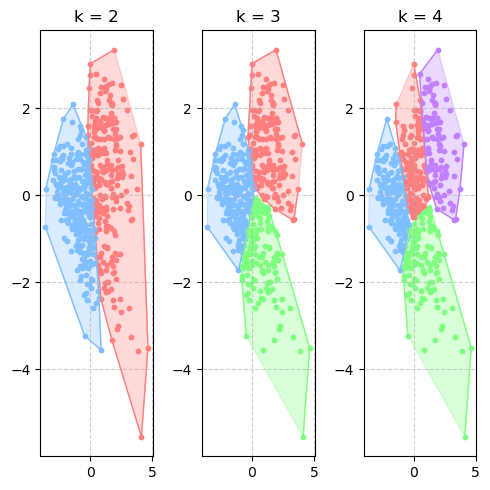

In [32]:
plt.figure(figsize=(5, 5))

for idx, k in enumerate([2, 3, 4]):
    plt.subplot(1, 3, idx+1)
    plot_clusters(df_pca, k)
    plt.title(f'k = {k}')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [33]:
# k-means ile ne elde ettik? Verinin özellikle ikili ve bir miktar da
# üçlü grup ile sınıflandırılabileceğini gördük. 

## 1.4. Importance ranking

Random Forest gibi bazı modellerin iç özellik olarak özellikleri sıralayan işlevleri vardır. Bundan yararlanacağız. Böyle bir özellik olmasaydı, farklı değişken kümeleri ile eğitim yapıp hangi değişkenin sonucu daha fazla etkilediğini bulmamız gerekecekti. Bunu da permutation importance metodu ile yapabiliriz.

In [34]:
from sklearn.ensemble import RandomForestClassifier

In [35]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

<Axes: >

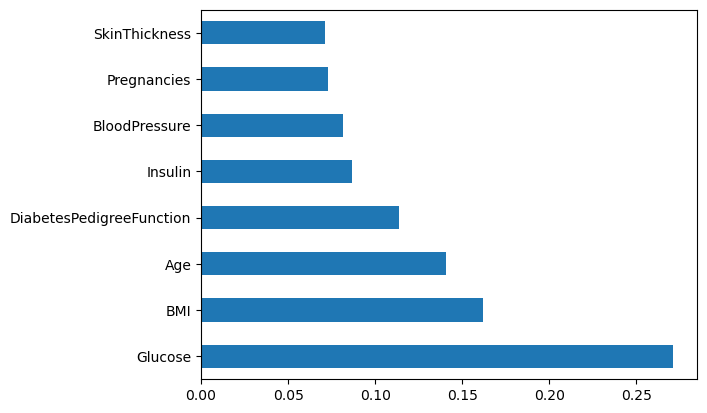

In [36]:
importances = rfc.feature_importances_
feat_importances = pd.Series(importances, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh')

### Permutation importance

In [37]:
from sklearn.inspection import permutation_importance

In [38]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [39]:
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

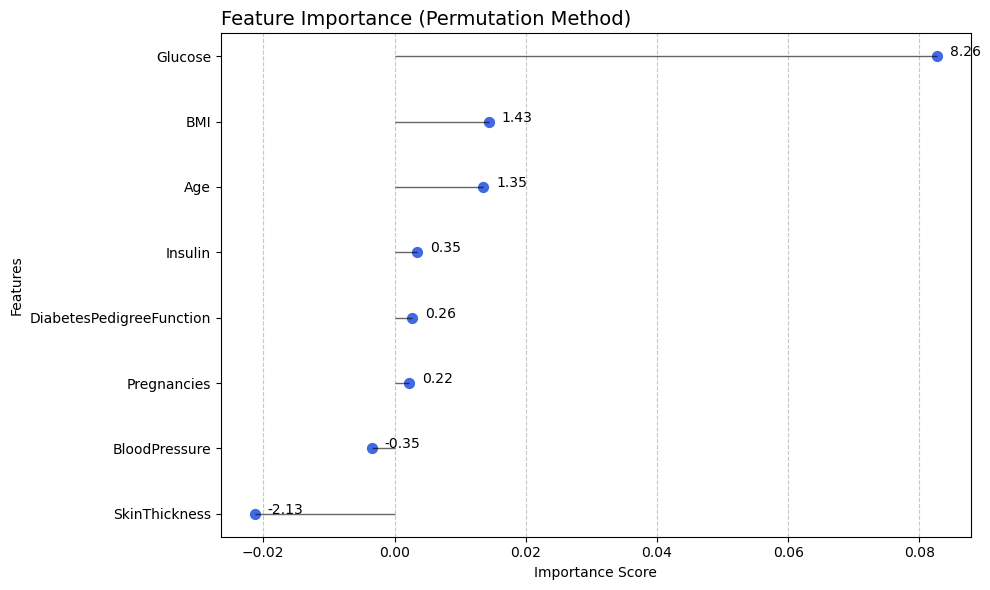

In [40]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=True) # Küçükten büyüğe (grafik için)

# Lolipop Grafiği Çizimi
plt.figure(figsize=(10, 6))

# Yatay çizgileri çiz (Gövde)
plt.hlines(y=importance_df['feature'], xmin=0, xmax=importance_df['importance'], 
           color='black', alpha=0.6, linewidth=1)

# Uçlardaki noktaları çiz (Kafa)
plt.scatter(importance_df['importance'], importance_df['feature'], 
            color='royalblue', s=50, alpha=1)

# Görselleştirmeyi güzelleştir
plt.title('Feature Importance (Permutation Method)', loc='left', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Sağ tarafa değerleri yazdırma (Opsiyonel)
for i, row in importance_df.iterrows():
    plt.text(row['importance'] + 0.002, row['feature'], f"{row['importance']*100:.2f}")

plt.tight_layout()
plt.show()

Genel olarak her iki yöntem de benzer sonuçları üretti. Fark sadece DPF ile Deri kalınlığı özelliklerinde görüldü. Eksi yönde, deri kalınlığı önemli bir etken olarak görülüyor. 
Modeller eğitilirken değişken seçimi için yaptığımız işlemlerin sonuçlarına göre üç farklı veri seti ile eğitim karşılaştırılacak:

    1. Tüm set
    2. Glucose, BMI ve Age değişkenlerinden oluşan üçlü set
    3. Glucose, BMI, Age, Insulin ve SkinThickness değişkenlerinden oluşan beşli set

# 2. Modeller

In [41]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [42]:
triple = ["Glucose", "BMI","Age"]
penta = ["Glucose", "BMI","Age","Insulin", "SkinThickness"]

In [43]:
X_train_3 = X_train[triple]
X_train_5 = X_train[penta]

## 2.1. Naive Bayes

In [44]:
nbc = GaussianNB()
nbc3 = GaussianNB()
nbc5 = GaussianNB()

In [45]:
nbc.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [46]:
nbc3.fit(X_train_3, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [47]:
nbc5.fit(X_train_5, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## 2.2. Decision Tree

In [48]:
dtc = DecisionTreeClassifier()
dtc3 = DecisionTreeClassifier()
dtc5 = DecisionTreeClassifier()

In [49]:
dtc.fit(X_train, y_train)
dtc3.fit(X_train[triple], y_train)
dtc5.fit(X_train[penta], y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

## 2.3. Random Forest

In [50]:
rfc = RandomForestClassifier()
rfc3 = RandomForestClassifier()
rfc5 = RandomForestClassifier()

In [51]:
rfc.fit(X_train, y_train)
rfc3.fit(X_train[triple], y_train)
rfc5.fit(X_train[penta], y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 2.4. Tahminler

In [52]:
y_pred_nb = nbc.predict(X_test)
y_pred_nb3 = nbc3.predict(X_test[triple])
y_pred_nb5 = nbc5.predict(X_test[penta])

In [53]:
y_pred_tree= dtc.predict(X_test)
y_pred_tree_3 = dtc3.predict(X_test[triple])
y_pred_tree_5 = dtc5.predict(X_test[penta])

In [54]:
y_pred_rf = rfc.predict(X_test)
y_pred_rf_3 = rfc3.predict(X_test[triple])
y_pred_rf_5 = rfc5.predict(X_test[penta])

# 3. Karşılaştırma

In [55]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [56]:
table_list = ["Accuracy","Precision","Sensitivity","Specifity","F_score"]

In [57]:
def statistical_score(model, x_test_):
    score = {}
    y_pred = model.predict(x_test_)

    score["Accuracy"]= round(accuracy_score(y_test,y_pred),2)
    score["Precision"] = round(precision_score(y_test, y_pred),2)
    score["Sensitivity"] = round(recall_score(y_test, y_pred),2)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    score["Specificity"] = round(float(tn / (tn + fp)),2)
    score["F1-Score"] = round(f1_score(y_test, y_pred),2)
    return score

In [58]:
nb_score = statistical_score(nbc, X_test)
nb3_score = statistical_score(nbc3, X_test[triple])
nb5_score = statistical_score(nbc5, X_test[penta])

In [59]:
dt_score = statistical_score(dtc, X_test)
dt3_score = statistical_score(dtc3, X_test[triple])
dt5_score = statistical_score(dtc5, X_test[penta])

In [60]:
rf_score = statistical_score(rfc, X_test)
rf3_score = statistical_score(rfc3, X_test[triple])
rf5_score = statistical_score(rfc5, X_test[penta])

In [61]:
data = [dt_score, rf_score, nb_score]

# DataFrame oluşturun ve index isimlerini belirleyin
df_whole = pd.DataFrame(data, index= ["Decision Tree", "Random Forest", "Naive Bayes"])

In [62]:
print("Tam özellikli model\n")
df_whole

Tam özellikli model



,Accuracy,Precision,Sensitivity,Specificity,F1-Score
Decision Tree,0.71,0.57,0.69,0.72,0.62
Random Forest,0.74,0.62,0.68,0.78,0.65
Naive Bayes,0.74,0.62,0.65,0.79,0.63


In [63]:
data3 = [dt3_score, rf3_score, nb3_score]

# DataFrame oluşturun ve index isimlerini belirleyin
df_3 = pd.DataFrame(data3, index= ["Decision Tree", "Random Forest", "Naive Bayes"])
print("3 özellikli model\n")
df_3

3 özellikli model



,Accuracy,Precision,Sensitivity,Specificity,F1-Score
Decision Tree,0.66,0.51,0.54,0.72,0.52
Random Forest,0.73,0.60,0.65,0.77,0.62
Naive Bayes,0.73,0.61,0.59,0.80,0.60


In [64]:
data5 = [dt5_score, rf5_score, nb5_score]

# DataFrame oluşturun ve index isimlerini belirleyin
df_5 = pd.DataFrame(data5, index= ["Decision Tree", "Random Forest", "Naive Bayes"])
print("5 özellikli model\n")
df_5

5 özellikli model



,Accuracy,Precision,Sensitivity,Specificity,F1-Score
Decision Tree,0.67,0.52,0.62,0.69,0.56
Random Forest,0.73,0.60,0.65,0.77,0.63
Naive Bayes,0.73,0.63,0.59,0.81,0.61


# 4. Grafik karşılaştırma

Her bir model için perfromans metriklerinin değişken seçimine göre karşılaştırması yapıldığında; çok büyük farkların olmadığı ve dolayısıyla 8 değişkenin tümünü kullanmadan da bir modelin eğitilebileceğini görmüş olduk. 

In [68]:
import seaborn as sns

In [69]:
def score_data(feature):
    df = pd.concat([df_whole[feature],df_3[feature], df_5[feature]], axis=1)
    return df.values.reshape(9,)

In [70]:
def plotting_score(feature):

    
    # 1. Veri Setini Oluşturma (Görseldeki değerlere yaklaşık olarak)
    data = {
        'Model': ['Decision Tree', 'Decision Tree', 'Decision Tree',
                'Naïve Bayes', 'Naïve Bayes', 'Naïve Bayes',
                'Random Forest', 'Random Forest', 'Random Forest'],
        'Feature Selection': ['3 features', '5 features', 'All features',
                            '3 features', '5 features', 'All features',
                            '3 features', '5 features', 'All features'],
        feature: score_data(feature)
    }

    df = pd.DataFrame(data)

    # 2. Grafik Stilini Ayarlama
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # 3. Gruplandırılmış Sütun Grafiği Çizimi
    plot = sns.barplot(
        data=df, 
        x='Model', 
        y=feature, 
        hue='Feature Selection', 
        palette=['#4472C4', '#ED7D31', '#A5A5A5'] # Görseldeki renk tonları
    )

    # 4. Görsel Detaylar
    plt.title(feature, fontsize=16)
    plt.ylim(0, 1.0) # Y eksenini 0 ile 1 arasına sabitle
    plt.ylabel('')   # Y ekseni etiketini kaldır (görseldeki gibi)
    plt.xlabel('')   # X ekseni etiketini kaldır
    plt.legend(title='', loc='upper left', bbox_to_anchor=(0.1, 1)) # Legend konumu

    # Çizgileri belirginleştirme
    plt.gca().yaxis.grid(True)

    plt.show()

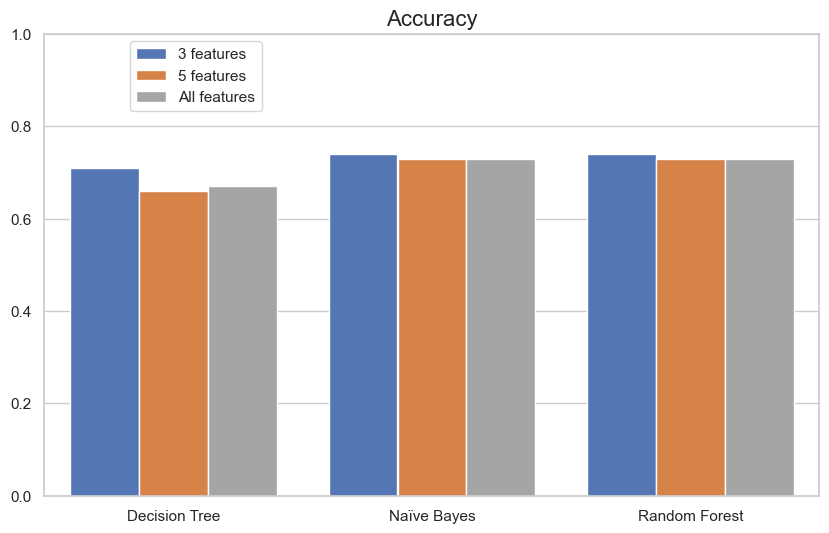

In [72]:
plotting_score("Accuracy")

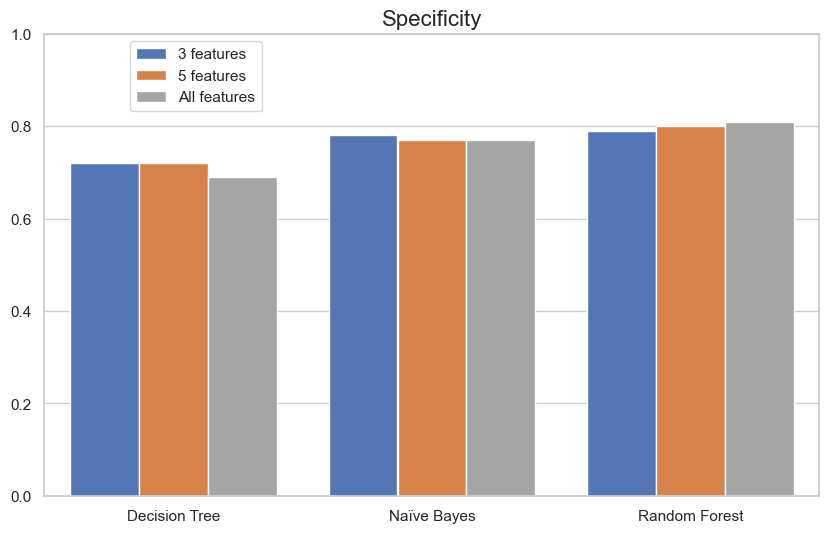

In [73]:
plotting_score("Specificity")

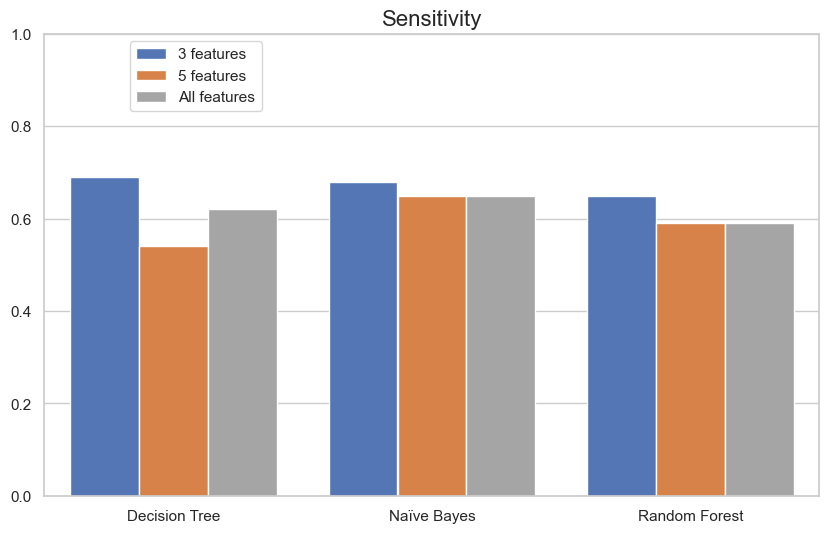

In [74]:
plotting_score("Sensitivity")